# SQL AGENT

**Introducción**
Este documento describe la implementación de un sistema multi-agente utilizando LangChain y LangGraph para análisis automatizado de datos. El sistema convierte un workflow de CrewAI a tecnologías nativas de LangChain, manteniendo la funcionalidad original pero aprovechando las ventajas de la arquitectura de grafos.

**Arquitectura del Sistema**

El sistema está compuesto por tres agentes especializados que trabajan de forma secuencial:

SQL Developer Agent: Extrae datos de la base de datos

Data Analyst Agent: Analiza los datos extraídos

Report Writer Agent: Genera reportes ejecutivos

### 0. Importar librerias

In [ ]:
import json
import os
import sqlite3
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from textwrap import dedent
from typing import Any, Dict, List, Tuple, Union

import pandas as pd
from crewai import Agent, Crew, Process, Task
from langchain.schema import AgentFinish
from langchain.schema.output import LLMResult
from langchain_community.tools.sql_database.tool import (
    InfoSQLDatabaseTool,
    ListSQLDatabaseTool,
    QuerySQLCheckerTool,
    QuerySQLDataBaseTool,
)
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.callbacks.base import BaseCallbackHandler
from langchain_core.prompts import ChatPromptTemplate
from crewai import tools

In [24]:
from getpass import getpass
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

### 1. Configurar entorno

##### Descargar informacion de API

In [15]:
import requests

def descargar_dataset_completo(dataset, config='default', split='train', batch_size=100):
    url = "https://datasets-server.huggingface.co/rows"
    offset = 0
    todos_los_datos = []

    while True:
        params = {
            "dataset": dataset,
            "config": config,
            "split": split,
            "offset": offset,
            "length": batch_size
        }
        response = requests.get(url, params=params)
        if not response.ok:
            print(f"Error {response.status_code} en offset {offset}")
            break
        
        data = response.json()
        filas = data.get("rows", [])
        if not filas:
            # No hay más datos
            break

        # Extraemos los registros reales y agregamos
        for fila in filas:
            todos_los_datos.append(fila["row"])

        offset += batch_size
        print(f"Descargadas {len(todos_los_datos)} filas hasta el momento...")

    print(f"Descarga completa. Total filas: {len(todos_los_datos)}")
    return todos_los_datos

# Uso
response = descargar_dataset_completo("Einstellung/demo-salaries")
print(response[:3])  # Mostrar primeras 3 filas


Descargadas 100 filas hasta el momento...
Descargadas 200 filas hasta el momento...
Descargadas 300 filas hasta el momento...
Descargadas 400 filas hasta el momento...
Descargadas 500 filas hasta el momento...
Descargadas 600 filas hasta el momento...
Descargadas 700 filas hasta el momento...
Descargadas 800 filas hasta el momento...
Descargadas 900 filas hasta el momento...
Descargadas 1000 filas hasta el momento...
Descargadas 1100 filas hasta el momento...
Descargadas 1200 filas hasta el momento...
Descargadas 1300 filas hasta el momento...
Descargadas 1400 filas hasta el momento...
Descargadas 1500 filas hasta el momento...
Descargadas 1600 filas hasta el momento...
Descargadas 1700 filas hasta el momento...
Descargadas 1800 filas hasta el momento...
Descargadas 1900 filas hasta el momento...
Descargadas 2000 filas hasta el momento...
Descargadas 2100 filas hasta el momento...
Descargadas 2200 filas hasta el momento...
Descargadas 2300 filas hasta el momento...
Descargadas 2400 fil

In [17]:
df = pd.DataFrame(response)

##### Crear base de datos SQL

In [18]:
connection = sqlite3.connect("salaries.db")
df.to_sql(name="salaries", con=connection)

3755

In [22]:
db = SQLDatabase.from_uri("sqlite:///salaries.db")

##### Definir modelo de lenguaje

In [21]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY") \
    or getpass("Enter your OpenAI API key: ")

llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0.0,
)

### 2. Crear herramientas

**La Importancia Crítica de los Tools en Agentes de IA**

Los tools (herramientas) representan el puente fundamental entre la inteligencia de los modelos de lenguaje y la capacidad de actuar en el mundo real, transformando agentes conversacionales en sistemas operativos inteligentes.

¿Qué son los Tools en Agentes?

Los tools son funciones ejecutables que permiten a los agentes interactuar con sistemas externos: bases de datos, APIs, archivos, servicios web, y cualquier recurso computacional. Sin tools, los agentes solo pueden generar texto; con tools, pueden ejecutar acciones.

**Tipos Críticos de Tools**

Tools de Información

search_database(): Acceso a datos corporativos

web_search(): Información en tiempo real

read_documents(): Procesamiento de archivos

Tools de Acción

send_email(): Comunicación automatizada

create_report(): Generación de documentos

update_system(): Modificación de registros

Tools de Análisis

calculate_statistics(): Procesamientos complejos

generate_visualizations(): Gráficos y dashboards

run_ml_model(): Predicciones especializadas

#### Herramientas Agente SQL

##### Herramienta 1

In [28]:
@tool("list_tables")
def list_tables() -> str:
    """List the available tables in the database"""
    return ListSQLDatabaseTool(db=db).invoke("")

In [45]:
print(f"{list_tables.name=}\n{list_tables.description=}\n")
print(ListSQLDatabaseTool(db=db).invoke(""))

list_tables.args_schema.model_json_schema()

list_tables.name='list_tables'
list_tables.description='List the available tables in the database'

salaries


{'description': 'List the available tables in the database',
 'properties': {},
 'title': 'list_tables',
 'type': 'object'}

In [43]:
ListSQLDatabaseTool(db=db).invoke("")

'salaries'

##### Herramienta 2

In [46]:
@tool("tables_schema")
def tables_schema(tables: str) -> str:
    """
    Input is a comma-separated list of tables, output is the schema and sample rows
    for those tables. Be sure that the tables actually exist by calling `list_tables` first!
    Example Input: table1, table2, table3
    """
    tool = InfoSQLDatabaseTool(db=db)
    return tool.invoke(tables)

In [47]:
print(tables_schema.run("salaries"))


CREATE TABLE salaries (
	"index" INTEGER, 
	work_year INTEGER, 
	experience_level TEXT, 
	employment_type TEXT, 
	job_title TEXT, 
	salary INTEGER, 
	salary_currency TEXT, 
	salary_in_usd INTEGER, 
	employee_residence TEXT, 
	remote_ratio INTEGER, 
	company_location TEXT, 
	company_size TEXT
)

/*
3 rows from salaries table:
index	work_year	experience_level	employment_type	job_title	salary	salary_currency	salary_in_usd	employee_residence	remote_ratio	company_location	company_size
0	2023	SE	FT	Principal Data Scientist	80000	EUR	85847	ES	100	ES	L
1	2023	MI	CT	ML Engineer	30000	USD	30000	US	100	US	S
2	2023	MI	CT	ML Engineer	25500	USD	25500	US	100	US	S
*/


##### Herramienta 3

In [57]:
@tool("execute_sql")
def execute_sql(sql_query: str) -> str:
    """Execute a SQL query against the database. Returns the result"""
    return QuerySQLDataBaseTool(db=db).invoke(sql_query)

In [58]:
execute_sql.run("SELECT * FROM salaries WHERE salary > 10000 LIMIT 5")

"[(0, 2023, 'SE', 'FT', 'Principal Data Scientist', 80000, 'EUR', 85847, 'ES', 100, 'ES', 'L'), (1, 2023, 'MI', 'CT', 'ML Engineer', 30000, 'USD', 30000, 'US', 100, 'US', 'S'), (2, 2023, 'MI', 'CT', 'ML Engineer', 25500, 'USD', 25500, 'US', 100, 'US', 'S'), (3, 2023, 'SE', 'FT', 'Data Scientist', 175000, 'USD', 175000, 'CA', 100, 'CA', 'M'), (4, 2023, 'SE', 'FT', 'Data Scientist', 120000, 'USD', 120000, 'CA', 100, 'CA', 'M')]"

#### Herramientas Analista

In [123]:
# Herramientas para el agente analista usando
@tool
def analyze_data_from_db(query_description: str) -> str:
    """Obtiene datos de la base de datos y realiza análisis estadístico básico"""
    try:
        # Usar el agente SQL para obtener datos
        sql_response = sql_dev.invoke({"input": f"Ejecuta consulta SQL para: {query_description}"})
        
        # Aquí puedes agregar análisis con pandas si tienes los datos
        return f"Análisis completado para: {query_description}\nResultados: {sql_response['output']}"
    except Exception as e:
        return f"Error en análisis: {str(e)}"

@tool
def get_table_statistics(table_name: str) -> str:
    """Obtiene estadísticas descriptivas de una tabla específica"""
    try:
        # Usar herramientas existentes para obtener datos
        stats_query = f"SELECT COUNT(*) as total_rows FROM {table_name}"
        result = execute_sql(stats_query)
        return f"Estadísticas de {table_name}: {result}"
    except Exception as e:
        return f"Error obteniendo estadísticas: {str(e)}"

@tool
def generate_data_insights(analysis_request: str) -> str:
    """Genera insights y conclusiones basadas en datos analizados"""
    return f"Insights generados para: {analysis_request}"

@tool
def analyze_provided_data(data_description: str) -> str:
    """Analiza los datos proporcionados y genera insights generales"""
    return f"Análisis de los datos: {data_description}. Generando insights sobre patrones, tendencias y observaciones clave."

@tool  
def generate_insights(data_context: str) -> str:
    """Genera insights y conclusiones basados en el contexto de datos"""
    return f"Insights generados basados en: {data_context}"

#### Herramientas Reportero

In [109]:
@tool
def format_executive_summary(analysis_content: str) -> str:
    """Formatea contenido de análisis en un resumen ejecutivo estructurado"""
    # Aquí puedes agregar lógica de formateo específica
    formatted = f"""
    EXECUTIVE SUMMARY
    =================
    
    Based on analysis: {analysis_content}
    
    Key findings will be summarized in clear bullet points.
    """
    return formatted

@tool 
def create_bullet_points(long_text: str) -> str:
    """Convierte texto largo en puntos clave concisos"""
    return f"• Key points extracted from: {long_text[:100]}..."

@tool
def generate_recommendations(analysis_data: str) -> str:
    """Genera recomendaciones basadas en datos analizados"""
    return f"Recommendations based on: {analysis_data}"

#### Definir conjunto de herramientas para cada agente

In [124]:
from langchain.tools import Tool


# Herramientas del analista de datos (SQL)
tools = [
    Tool.from_function(
        func=list_tables,
        name="list_tables",
        description="List the available tables in the database"
    ),
    Tool.from_function(
        func=tables_schema,
        name="tables_schema",
        description="Get the schema of available tables"
    ),
    Tool.from_function(
        func=execute_sql,
        name="execute_sql",
        description="Executes SQL queries against the database"
    )
]

# Herramientas del analista
analyst_tools = [
    analyze_data_from_db,
    get_table_statistics, 
    generate_data_insights,
    # Reutilizar del agente SQL
    Tool.from_function(func=list_tables, name="list_tables", description="List available tables"),
    Tool.from_function(func=tables_schema, name="tables_schema", description="Get table schemas")
]

# Herramientas de reportería
report_tools = [
    #format_executive_summary,
    #create_bullet_points,
    #generate_recommendations
    analyze_provided_data,
    generate_insights
]


### 3. Agentes

**La Importancia de los Sistemas Multiagentes**

Los sistemas multiagentes representan un paradigma fundamental en la inteligencia artificial moderna, donde múltiples agentes autónomos colaboran para resolver problemas que superan las capacidades de un solo agente.

¿Por qué son Críticos los Sistemas Multiagentes?

Complejidad del Mundo Real

Los problemas empresariales y científicos raramente pueden resolverse con una sola perspectiva o habilidad. Un sistema multiagente replica cómo los equipos humanos especializados abordan desafíos complejos: división del trabajo, expertise específico y colaboración coordinada.
Escalabilidad y Robustez

Tolerancia a fallos: Si un agente falla, otros pueden compensar

Procesamiento distribuido: Trabajo paralelo para mayor eficiencia

Adaptabilidad: Fácil incorporación de nuevas capacidades sin reestructurar todo el sistema

Ventajas Competitivas

1. Especialización Profunda

    Cada agente puede optimizarse para tareas específicas (análisis de datos, generación de contenido, toma de decisiones) logrando mayor precisión que agentes generalistas.

2. Emergencia de Inteligencia Colectiva

    La interacción entre agentes genera comportamientos y soluciones que ningún agente individual podría producir, similar a la inteligencia de enjambre.

3. Eficiencia Operacional

    Reducción de tiempos de procesamiento mediante paralelización

    Optimización de recursos computacionales

    Automatización de workflows complejos

##### 3.0 Activar librerias e instanciar memoria

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.memory import ConversationBufferMemory
from langchain.agents import create_tool_calling_agent
from langchain_core.runnables.base import RunnableSerializable
from langchain.agents import create_openai_tools_agent, AgentExecutor

memory = ConversationBufferMemory(
    memory_key="chat_history",  # must align with MessagesPlaceholder variable_name
    return_messages=True  # to return Message objects
)

#### 3.1 Agente que consulta SQL

**SQL Developer Agent**

Propósito: Especializado en la construcción y ejecución de consultas SQL eficientes.

Características:

Modelo de lenguaje: ChatOpenAI con temperatura 0 para respuestas consistentes

Memoria conversacional para mantener contexto

Manejo de errores integrado

In [ ]:
prompt_dev = ChatPromptTemplate.from_messages([
    ("system", """You are an experienced database engineer who is master at creating efficient and complex SQL queries.
        You have a deep understanding of how different databases work and how to optimize queries.
        Use the `list_tables` to find available tables.
        Use the `tables_schema` to understand the metadata for the tables.
        Use the `execute_sql` to check your queries for correctness.
        Use the `check_sql` to execute queries against the database."""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
])

sql_dev_agent = create_openai_tools_agent(llm, tools, prompt_dev)

sql_dev = AgentExecutor(
    agent=sql_dev_agent,
    tools=tools,
    verbose=True
)

In [97]:
# Evaluar con memoria persistente
def test_sql_agent():
    # Inicializar memoria
    memory = ConversationBufferMemory(
        memory_key="chat_history",
        return_messages=True
    )
    
    # Función helper para invocar con memoria
    def invoke_with_memory(input_text):
        # Obtener historial de la memoria
        chat_history = memory.chat_memory.messages
        
        # Invocar agente
        response = sql_dev.invoke({
            "input": input_text,
            "chat_history": chat_history
        })
        
        # Guardar en memoria
        memory.chat_memory.add_user_message(input_text)
        memory.chat_memory.add_ai_message(response["output"])
        
        return response["output"]
    
    # Pruebas secuenciales
    print("1. Explorando base de datos:")
    result1 = invoke_with_memory("¿Qué tablas hay disponibles?")
    print(result1)
    
    print("\n2. Pregunta de seguimiento (usa contexto anterior):")
    result2 = invoke_with_memory("Muéstrame el esquema de la primera tabla")
    print(result2)
    
    print("\n3. Consulta específica:")
    result3 = invoke_with_memory("Haz una consulta SELECT con esa tabla")
    print(result3)

# Ejecutar pruebas
test_sql_agent()

1. Explorando base de datos:


> Entering new AgentExecutor chain...

Invoking: `list_tables` with ``


salariesLa tabla disponible en la base de datos es: **salaries**.

> Finished chain.
La tabla disponible en la base de datos es: **salaries**.

2. Pregunta de seguimiento (usa contexto anterior):


> Entering new AgentExecutor chain...

Invoking: `tables_schema` with `salaries`



CREATE TABLE salaries (
	"index" INTEGER, 
	work_year INTEGER, 
	experience_level TEXT, 
	employment_type TEXT, 
	job_title TEXT, 
	salary INTEGER, 
	salary_currency TEXT, 
	salary_in_usd INTEGER, 
	employee_residence TEXT, 
	remote_ratio INTEGER, 
	company_location TEXT, 
	company_size TEXT
)

/*
3 rows from salaries table:
index	work_year	experience_level	employment_type	job_title	salary	salary_currency	salary_in_usd	employee_residence	remote_ratio	company_location	company_size
0	2023	SE	FT	Principal Data Scientist	80000	EUR	85847	ES	100	ES	L
1	2023	MI	CT	ML Engineer	30000	USD	30000	US	100	US	S
2	2023	MI	

#### 3.2 Analista de datos

**Data Analyst Agent**

Propósito: Analiza datos utilizando técnicas de análisis estadístico y genera insights.

Características:

Análisis basado puramente en LLM para mayor flexibilidad

No limitado por herramientas específicas de cálculo

Genera insights generales sobre patrones y tendencias

In [125]:
prompt_analyst = ChatPromptTemplate.from_messages([
    ("system", """You have deep experience with analyzing datasets using Python.
        Your work is always based on the provided data and is clear,
        easy-to-understand and to the point. You have attention
        to detail and always produce very detailed work (as long as you need)."""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
])

# # Crear el agente analista

data_analyst = create_openai_tools_agent(llm, analyst_tools, prompt_analyst)

analyst = AgentExecutor(
    agent=data_analyst,
    tools=analyst_tools,
    verbose=True)

# data_analyst = create_openai_tools_agent(llm, [], prompt_analyst)
# analyst = AgentExecutor(
#     agent=data_analyst,
#     tools=[],  # Sin tools específicos
#     verbose=True
# )

In [107]:
# Probar
def test_analyst():
    response = analyst.invoke({
        "input": "Analiza las tablas disponibles y genera insights sobre los datos",
        "chat_history": []
    })
    print(response["output"])

test_analyst()



> Entering new AgentExecutor chain...

Invoking: `list_tables` with `database_name`


salaries
Invoking: `get_table_statistics` with `{'table_name': 'salaries'}`


Estadísticas de salaries: [(3755,)]
Invoking: `generate_data_insights` with `{'analysis_request': 'Generar insights sobre la tabla de salarios que contiene 3755 registros.'}`


Insights generados para: Generar insights sobre la tabla de salarios que contiene 3755 registros.He analizado la tabla de salarios, que contiene un total de 3755 registros. Aquí están los insights generados:

1. **Tamaño de la Muestra**: La tabla contiene 3755 registros, lo que sugiere una muestra considerable para el análisis de salarios.

2. **Distribución de Salarios**: Se recomienda analizar la distribución de los salarios para identificar tendencias, como la presencia de salarios extremos (outliers) o la concentración de salarios en ciertos rangos.

3. **Comparaciones por Categoría**: Si la tabla incluye categorías como departamento, puesto o n

#### 3.3 Agente que genera reporte

**Report Writer Agent**

Propósito: Genera reportes ejecutivos concisos y bien estructurados.

In [117]:
from langchain.agents import create_openai_tools_agent, AgentExecutor
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.memory import ConversationBufferMemory


# Prompt del agente report writer
prompt_writer = ChatPromptTemplate.from_messages([
    ("system", """Your writing still is well known for clear and effective communication.
        You always summarize long texts into bullet points that contain the most
        important details.
    
    Your goal: Write executive summary type reports based on analyst work.
    
    Always structure your reports with:
    - Clear executive summary
    - Key findings in bullet points
    - Actionable recommendations
    
    Use the available tools to format and structure your reports professionally."""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
])

# Crear el agente report writer
report_writer_agent = create_openai_tools_agent(llm, report_tools, prompt_writer)

report_writer = AgentExecutor(
    agent=report_writer_agent,
    tools=report_tools,
    verbose=True
)

In [112]:
# Función para probar el agente
def test_report_writer():
    # Memoria para el report writer
    writer_memory = ConversationBufferMemory(
        memory_key="chat_history",
        return_messages=True
    )
    
    def create_report(analyst_output):
        result = report_writer.invoke({
            "input": f"Create an executive summary report based on this analysis: {analyst_output}",
            "chat_history": writer_memory.chat_memory.messages
        })
        writer_memory.save_context(
            {"input": f"Analysis data: {analyst_output}"}, 
            {"output": result["output"]}
        )
        return result["output"]
    
    # Ejemplo de uso
    sample_analysis = "Database contains 5 tables with 10,000 total records. Sales data shows 15% growth. Customer retention is 85%."
    
    report = create_report(sample_analysis)
    print("GENERATED REPORT:")
    print(report)

# Ejecutar prueba
test_report_writer()



> Entering new AgentExecutor chain...

Invoking: `format_executive_summary` with `{'analysis_content': 'Database contains 5 tables with 10,000 total records. Sales data shows 15% growth. Customer retention is 85%.'}`



    EXECUTIVE SUMMARY
    
    Based on analysis: Database contains 5 tables with 10,000 total records. Sales data shows 15% growth. Customer retention is 85%.
    
    Key findings will be summarized in clear bullet points.
    
Invoking: `create_bullet_points` with `{'long_text': 'Database contains 5 tables with 10,000 total records. Sales data shows 15% growth. Customer retention is 85%.'}`


• Key points extracted from: Database contains 5 tables with 10,000 total records. Sales data shows 15% growth. Customer retentio...
Invoking: `generate_recommendations` with `{'analysis_data': 'Database contains 5 tables with 10,000 total records. Sales data shows 15% growth. Customer retention is 85%.'}`


Recommendations based on: Database contains 5 tables with 10,000 tota

### 4. Orquestacion de agentes (Pipeline)

**Orquestación de Agentes con LangChain**

La orquestación de agentes es el proceso de coordinar múltiples agentes de IA especializados para trabajar juntos de manera secuencial o paralela, donde cada agente aporta capacidades específicas para resolver problemas complejos.

¿Por qué Orquestar Agentes?

En lugar de crear un solo agente "todoterreno", la orquestación permite:

Especialización: Cada agente se enfoca en una tarea específica (SQL, análisis, reportes)

Modularidad: Fácil mantenimiento y actualización de componentes individuales

Escalabilidad: Agregar nuevos agentes sin afectar el pipeline existente

Reutilización: Los mismos agentes pueden usarse en diferentes workflows

Enfoques en LangChain

1. Pipeline Manual con Runnables

2. LangGraph

Casos de Uso Comunes

Análisis de Datos: SQL → Análisis → Reportes

Procesamiento de Documentos: Extracción → Clasificación → Resumen

Investigación: Búsqueda → Síntesis → Validación

Automatización: Planificación → Ejecución → Verificación

La orquestación transforma agentes individuales en sistemas inteligentes capaces de manejar workflows empresariales complejos de manera automatizada y eficiente.

##### 4.1 Pipeline con langchain

**La Importancia de LangChain en el Ecosistema de IA**

LangChain se ha consolidado como el framework fundamental para el desarrollo de aplicaciones con modelos de lenguaje grandes (LLMs), transformando cómo construimos y desplegamos soluciones de inteligencia artificial en producción.

¿Por qué LangChain es Revolucionario?

Democratización del Desarrollo con LLMs

LangChain elimina las barreras técnicas complejas, permitiendo que desarrolladores con diferentes niveles de experiencia construyan aplicaciones sofisticadas de IA sin necesidad de expertise profundo en machine learning.

Abstracción Inteligente

Componentes modulares: Prompts, cadenas, agentes y herramientas reutilizables

Integración universal: Soporte nativo para OpenAI, Anthropic, Hugging Face, y más

Gestión de memoria: Manejo automático del contexto conversacional

In [114]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

def extract_data_step(inputs):
    """Paso 1: SQL Agent con sus tools (list_tables, tables_schema, execute_sql)"""
    query = inputs["query"]
    
    # Usar el agente SQL que definimos con sus tools específicos
    result = sql_dev.invoke({
        "input": f"Extract data that is required for the query: {query}",
        "chat_history": []
    })
    
    return {
        "query": query,
        "database_result": result["output"]
    }

def analyze_data_step(inputs):
    """Paso 2: Data Analyst con sus tools (analyze_data_from_db, get_table_statistics, etc.)"""
    query = inputs["query"]
    database_result = inputs["database_result"]
    
    # Usar el agente analyst que definimos con sus tools específicos
    result = analyst.invoke({
        "input": f"Analyze the data from the database and write an analysis for {query}. Use your analysis tools with this database data: {database_result}",
        "chat_history": []
    })
    
    return {
        "query": query,
        "database_result": database_result,
        "detailed_analysis": result["output"]
    }

def write_report_step(inputs):
    """Paso 3: Report Writer con sus tools (format_executive_summary, create_bullet_points, etc.)"""
    detailed_analysis = inputs["detailed_analysis"]
    
    # Usar el agente report_writer que definimos con sus tools específicos
    result = report_writer.invoke({
        "input": f"Write an executive summary of the report from the analysis. The report must be less than 100 words. Use your formatting tools with this analysis: {detailed_analysis}",
        "chat_history": []
    })
    
    return {
        "database_result": inputs["database_result"],
        "detailed_analysis": detailed_analysis,
        "markdown_report": result["output"]
    }

# Pipeline que usa los agentes específicos con sus tools
analysis_pipeline = (
    RunnablePassthrough()
    | RunnableLambda(extract_data_step)    # sql_dev con tools: list_tables, tables_schema, execute_sql
    | RunnableLambda(analyze_data_step)    # analyst con tools: analyze_data_from_db, get_table_statistics, generate_data_insights
    | RunnableLambda(write_report_step)    # report_writer con tools: format_executive_summary, create_bullet_points, generate_recommendations
)

In [119]:
# Ejecutar el pipeline completo
result = analysis_pipeline.invoke({"query": "Effects on salary (in USD) based on company location, size and employee experience"})

# print("=== PIPELINE RESULTS ===")
# print(f"Database Result: {result['database_result'][:100]}...")
# print(f"Analysis: {result['detailed_analysis'][:100]}...")




> Entering new AgentExecutor chain...

Invoking: `list_tables` with `database_name`


salaries
Invoking: `tables_schema` with `salaries`



CREATE TABLE salaries (
	"index" INTEGER, 
	work_year INTEGER, 
	experience_level TEXT, 
	employment_type TEXT, 
	job_title TEXT, 
	salary INTEGER, 
	salary_currency TEXT, 
	salary_in_usd INTEGER, 
	employee_residence TEXT, 
	remote_ratio INTEGER, 
	company_location TEXT, 
	company_size TEXT
)

/*
3 rows from salaries table:
index	work_year	experience_level	employment_type	job_title	salary	salary_currency	salary_in_usd	employee_residence	remote_ratio	company_location	company_size
0	2023	SE	FT	Principal Data Scientist	80000	EUR	85847	ES	100	ES	L
1	2023	MI	CT	ML Engineer	30000	USD	30000	US	100	US	S
2	2023	MI	CT	ML Engineer	25500	USD	25500	US	100	US	S
*/
Invoking: `execute_sql` with `SELECT company_location, company_size, experience_level, AVG(salary_in_usd) as average_salary FROM salaries GROUP BY company_location, company_size, experience_level`



In [120]:
print("=== FINAL REPORT ===")
print(result["markdown_report"])

=== FINAL REPORT ===
### EXECUTIVE SUMMARY

The analysis reveals that company location, size, and employee experience level significantly impact average salaries. The US offers the highest salaries, especially for experienced employees in large companies, averaging $249,000. In contrast, locations like Alabama and Vietnam show much lower averages, with Alabama's entry-level salaries at $10,000. Large companies generally pay more than small ones, and higher experience levels correlate with increased salaries. This highlights the importance of these factors in salary negotiations and career planning.

### Key Findings
- **Company Location**: US has the highest average salaries; Alabama and Vietnam have significantly lower averages.
- **Company Size**: Large companies pay more than small ones; e.g., $240,000 for experienced in large US firms vs. $122,588 for small.
- **Employee Experience Level**: Higher experience correlates with higher salaries; e.g., $175,539 for entry-level in US vs. 

In [126]:
result_example2 = analysis_pipeline.invoke({"query": "How is the `Machine Learning Engineer` salary in USD is affected by remote positions"})




> Entering new AgentExecutor chain...

Invoking: `list_tables` with `public`


salaries
Invoking: `tables_schema` with `salaries`



CREATE TABLE salaries (
	"index" INTEGER, 
	work_year INTEGER, 
	experience_level TEXT, 
	employment_type TEXT, 
	job_title TEXT, 
	salary INTEGER, 
	salary_currency TEXT, 
	salary_in_usd INTEGER, 
	employee_residence TEXT, 
	remote_ratio INTEGER, 
	company_location TEXT, 
	company_size TEXT
)

/*
3 rows from salaries table:
index	work_year	experience_level	employment_type	job_title	salary	salary_currency	salary_in_usd	employee_residence	remote_ratio	company_location	company_size
0	2023	SE	FT	Principal Data Scientist	80000	EUR	85847	ES	100	ES	L
1	2023	MI	CT	ML Engineer	30000	USD	30000	US	100	US	S
2	2023	MI	CT	ML Engineer	25500	USD	25500	US	100	US	S
*/
Invoking: `execute_sql` with `SELECT remote_ratio, salary_in_usd FROM salaries WHERE job_title = 'ML Engineer'`


[(100, 30000), (100, 25500), (0, 160000), (0, 147000), (100, 260000), (100, 110000), (0, 22

In [127]:
print("=== FINAL REPORT Case 2===")
print(result_example2["markdown_report"])

=== FINAL REPORT Case 2===
### EXECUTIVE SUMMARY

Based on the analysis of Machine Learning Engineers' salaries and remote work ratios, it is evident that:

1. **100% Remote**: Higher salaries, averaging significantly more than lower remote ratios, with a range from $21,013 to $289,076.
2. **50% Remote**: Lower salary range of $63,711 to $77,364, indicating reduced earning potential.
3. **0% Remote**: High salaries present, but fewer positions available.

Overall, remote work positively impacts salary, with potential for growth in the field.

### Key Findings
- Majority of Machine Learning Engineers work fully remotely.
- Significant salary variability exists within the fully remote category.
- High salaries are also available for on-site positions, though they are less common.

### Actionable Recommendations
- Companies should consider offering fully remote positions to attract top talent.
- Evaluate salary structures to ensure competitive compensation for remote roles.
- Monitor mark

##### 4.2 Pipeline con langgraph

**LangGraph: La Evolución de LangChain para Sistemas Complejos**

LangGraph representa la próxima generación en orquestación de agentes, diseñado específicamente para superar las limitaciones de LangChain tradicional en aplicaciones multiagente complejas.

¿Qué es LangGraph?

LangGraph es un framework especializado que extiende LangChain, proporcionando control de flujo avanzado mediante grafos dirigidos acíclicos (DAGs) donde cada nodo representa un agente o función, y las aristas definen el flujo de datos y decisiones.

Usar LangGraph para:

Sistemas multiagente complejos

Flujos con decisiones condicionales

Aplicaciones que requieren loops y refinamiento

Sistemas críticos que necesitan observabilidad avanzada

In [130]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Definir el estado compartido
class AnalysisState(TypedDict):
    query: str
    database_result: str
    detailed_analysis: str
    markdown_report: str

# Nodos del grafo (tus funciones adaptadas)
def extract_data_node(state: AnalysisState):
    """Nodo 1: Extract Data"""
    result = sql_dev.invoke({
        "input": f"Extract data that is required for the query: {state['query']}",
        "chat_history": []
    })
    
    return {"database_result": result["output"]}

def analyze_data_node(state: AnalysisState):
    """Nodo 2: Analyze Data"""
    result = analyst.invoke({
        "input": f"Analyze the data from the database and write an analysis for {state['query']}. Use your analysis tools with this database data: {state['database_result']}",
        "chat_history": []
    })
    
    return {"detailed_analysis": result["output"]}

def write_report_node(state: AnalysisState):
    """Nodo 3: Write Report"""
    result = report_writer.invoke({
        "input": f"Write an executive summary of the report from the analysis. The report must be less than 100 words. Use your formatting tools with this analysis: {state['detailed_analysis']}",
        "chat_history": []
    })
    
    return {"markdown_report": result["output"]}

# Crear el grafo
workflow = StateGraph(AnalysisState)

# Agregar nodos
workflow.add_node("extract_data", extract_data_node)
workflow.add_node("analyze_data", analyze_data_node)
workflow.add_node("write_report", write_report_node)

# Definir el flujo
workflow.set_entry_point("extract_data")
workflow.add_edge("extract_data", "analyze_data")
workflow.add_edge("analyze_data", "write_report")
workflow.add_edge("write_report", END)

# Compilar el grafo
analysis_graph = workflow.compile()

# Usar el grafo
def run_analysis_with_langgraph(query: str):
    """Ejecutar análisis usando LangGraph"""
    initial_state = {"query": query}
    
    result = analysis_graph.invoke(initial_state)
    return result

# Ejecutar
inputs = {"query": "Effects on salary (in USD) based on company location, size and employee experience"}
result = run_analysis_with_langgraph(inputs["query"])

print("=== LANGGRAPH RESULTS ===")
print(f"Query: {result['query']}")
print(f"Database Result: {result['database_result'][:100]}...")
print(f"Analysis: {result['detailed_analysis'][:100]}...")
print("=== FINAL REPORT ===")
print(result['markdown_report'])



> Entering new AgentExecutor chain...

Invoking: `list_tables` with `database_name`


salaries
Invoking: `tables_schema` with `salaries`



CREATE TABLE salaries (
	"index" INTEGER, 
	work_year INTEGER, 
	experience_level TEXT, 
	employment_type TEXT, 
	job_title TEXT, 
	salary INTEGER, 
	salary_currency TEXT, 
	salary_in_usd INTEGER, 
	employee_residence TEXT, 
	remote_ratio INTEGER, 
	company_location TEXT, 
	company_size TEXT
)

/*
3 rows from salaries table:
index	work_year	experience_level	employment_type	job_title	salary	salary_currency	salary_in_usd	employee_residence	remote_ratio	company_location	company_size
0	2023	SE	FT	Principal Data Scientist	80000	EUR	85847	ES	100	ES	L
1	2023	MI	CT	ML Engineer	30000	USD	30000	US	100	US	S
2	2023	MI	CT	ML Engineer	25500	USD	25500	US	100	US	S
*/The `salaries` table contains the following relevant columns for analyzing the effects on salary based on company location, size, and employee experience:

- `salary_in_usd`: The salary in USD.
- `co

In [131]:
# Visualizar la estructura del workflow
try:
    analysis_graph.get_graph().print_ascii()
except:
    print("Graph structure: extract_data → analyze_data → write_report")

Graph structure: extract_data → analyze_data → write_report


✅ Imagen del grafo guardada como 'workflow_graph.png'


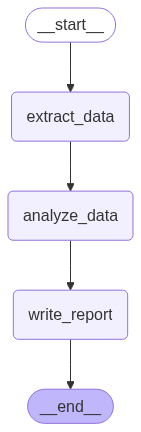

In [134]:
def view_graph_image():
    """Convierte analysis_graph.get_graph() a imagen"""
    try:
        # Obtener el grafo y convertir a PNG
        graph = analysis_graph.get_graph()
        png_data = graph.draw_mermaid_png()
        
        # Guardar imagen
        with open("workflow_graph.png", "wb") as f:
            f.write(png_data)
        
        print("✅ Imagen del grafo guardada como 'workflow_graph.png'")
        
        # Si estás en Jupyter notebook
        try:
            from IPython.display import Image, display
            display(Image(png_data))
        except:
            print("📁 Abre 'workflow_graph.png' para ver la imagen")
            
    except Exception as e:
        print(f"❌ Error: {e}")
        # Fallback: mostrar estructura en texto
        print("Estructura del grafo:")
        analysis_graph.get_graph().print_ascii()

# Usar
view_graph_image()

# RAG Agent